<a href="https://colab.research.google.com/github/WooHyunJ/DATATHON_9/blob/main/Datathon_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/final_csv11.csv')

In [ ]:
df.columns

Index(['SEQN', '공복혈당', 'HDL콜레스테롤', '중성지방', 'LDL콜레스테롤', '총콜레스테롤', '요산',
       '비타민B혈중농도', '커피섭취', '알콜섭취', '감기약복용여부', '위장약물복용여부', 'B형간염항체', '성별', '나이',
       '교육수준_청소년', '교육수준_성인', '연간가계소득', '60초맥박수', '규칙적맥박수', 'BMI지수', '악력',
       '수축기혈압', '이완기혈압', '키', '몸무게', '허리둘레', '당뇨진단여부', '혈당조절약복용여부', '고혈압진단여부',
       '혈압약복용여부', '유제품섭취빈도', '냉동식품섭취횟수', '1년 음주 빈도', '현재흡연여부', '하루평균수면시간',
       '주당운동빈도', '우울감경험여부', '활력수준', '체중조절 시도 여부', '하루좌식시간', '본인건강상태', '약복용일수',
       '복용한처방약수', '전반적건강상태', '지난12개월동안_헌혈했는지', '대사_복부비만', '대사_혈압', '대사_혈당',
       '대사_HDL', '대사_중성지방', '대사증후군_위험요인_수', '대사증후군_판정', '하루좌식시간_그룹', '소득_3단계',
       'high_sedentary', '좌식군'],
      dtype='object')

In [ ]:
df['냉동식품섭취횟수'] = df['냉동식품섭취횟수'].astype(int)

In [ ]:
df = df[df['주당운동빈도'] != 1.8]

In [ ]:
df = df[df['하루평균수면시간'] != 9]

In [ ]:
df['하루평균수면시간'].value_counts()

,count
하루평균수면시간,
2.0,2002
1.0,579


In [ ]:
import pandas as pd

# 10살 단위 연령대
bins = [0, 29, 39, 49, 59, 69, 120]
labels = ['20대 이하', '30대', '40대', '50대', '60대', '70대 이상']

df['연령대'] = pd.cut(df['나이'], bins=bins, labels=labels, right=True)


In [ ]:
target_cols = ['허리둘레','중성지방','HDL콜레스테롤','수축기혈압','이완기혈압', '공복혈당']

age_ratio = (
    df.groupby('연령대')[target_cols]
      .mean()                       # 평균 = 비율(0~1)
      .reset_index()
)

# %로 보기 쉽게 변환
age_ratio_pct = age_ratio.copy()
age_ratio_pct[target_cols] = age_ratio_pct[target_cols] * 100

print(age_ratio_pct.round(1))

      연령대     허리둘레     중성지방  HDL콜레스테롤    수축기혈압   이완기혈압     공복혈당
0  20대 이하   8652.5   8124.6    5260.8  11008.2  6212.5   9015.3
1     30대   9906.9  11762.0    5122.9  11654.8  7103.7   9398.1
2     40대   9918.2  12516.4    5107.9  11796.9  7157.9  10120.3
3     50대  10089.3  12403.9    5412.0  12432.4  7270.9  10714.2
4     60대  10235.6  11707.0    5415.0  13035.5  6974.3  11023.5
5  70대 이상  10205.2  11515.1    5439.9  13292.6  6513.4  10844.3


/tmp/ipython-input-1558745668.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('연령대')[target_cols]


In [ ]:
age_ratio_pct

,연령대,허리둘레,중성지방,HDL콜레스테롤,수축기혈압,이완기혈압,공복혈당
0,20대 이하,8652.548077,8124.639423,5260.817308,11008.173077,6212.500000,9015.264423
1,30대,9906.856383,11761.968085,5122.872340,11654.787234,7103.723404,9398.138298
2,40대,9918.164103,12516.410256,5107.948718,11796.923077,7157.948718,10120.256410
3,50대,10089.346369,12403.910615,5412.011173,12432.402235,7270.949721,10714.245810
4,60대,10235.639144,11707.033639,5414.984709,13035.474006,6974.311927,11023.547401
5,70대 이상,10205.174497,11515.100671,5439.932886,13292.617450,6513.422819,10844.295302


In [ ]:
#한글 글씨 폰트 설치
%%capture
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'

In [ ]:
# 허리둘레 기준 (남≥90cm, 여≥85cm 예시)
df['허리둘레_기준'] = (
    ((df['성별']==1) & (df['허리둘레'] >= 90)) |
    ((df['성별']==2) & (df['허리둘레'] >= 85))
).astype(int)

# 중성지방 ≥150 mg/dL
df['중성지방_기준'] = (df['중성지방'] >= 150).astype(int)

# HDL (남<40, 여<50)
df['HDL_기준'] = (
    ((df['성별']==1) & (df['HDL콜레스테롤'] < 40)) |
    ((df['성별']==2) & (df['HDL콜레스테롤'] < 50))
).astype(int)

# 수축기혈압 ≥130 또는 이완기혈압 ≥85
df['혈압_기준'] = (
    (df['수축기혈압'] >= 130) |
    (df['이완기혈압'] >= 85)
).astype(int)

# 공복혈당 ≥100 mg/dL
df['혈당_기준'] = (df['공복혈당'] >= 100).astype(int)

In [ ]:
df_40_70 = df[(df['나이'] >= 40) & (df['나이'] <= 70)].copy()

In [ ]:
criteria_cols = ['허리둘레_기준','중성지방_기준','HDL_기준','혈압_기준','혈당_기준']

df_40_70['기준_충족수'] = df_40_70[criteria_cols].sum(axis=1)

In [ ]:
df_40_70['대사증후군_위험군'] = (df_40_70['기준_충족수'] >= 3).astype(int)

In [ ]:
df_40_70['대사증후군_위험군'].value_counts()

,count
대사증후군_위험군,
0,680
1,418


In [ ]:
df_40_70[['나이','허리둘레','중성지방','HDL콜레스테롤',
          '수축기혈압','이완기혈압','공복혈당',
          '기준_충족수','대사증후군_위험군']].head()

,나이,허리둘레,중성지방,HDL콜레스테롤,수축기혈압,이완기혈압,공복혈당,기준_충족수,대사증후군_위험군
2,61.0,110.8,64.0,58.0,124.0,80.0,107.0,2,0
7,50.0,99.3,93.0,78.0,132.0,80.0,104.0,3,1
9,57.0,117.8,87.0,56.0,130.0,76.0,105.0,3,1
13,43.0,102.6,312.0,49.0,128.0,84.0,84.0,2,0
16,43.0,100.3,49.0,43.0,136.0,82.0,97.0,3,1


In [ ]:
# 40~70세 필터링
df_40_70 = df[(df['나이'] >= 40) & (df['나이'] <= 70)].copy()

# 기준 5개 합산
criteria_cols = ['허리둘레_기준','중성지방_기준','HDL_기준','혈압_기준','혈당_기준']
df_40_70['기준_충족수'] = df_40_70[criteria_cols].sum(axis=1)

# 대사증후군 위험군(1) vs 대조군(0)
df_40_70['대사증후군_위험군'] = (df_40_70['기준_충족수'] >= 3).astype(int)

# 나이 통계검정

In [ ]:
import scipy.stats as stats
import numpy as np
import pandas as pd

# ==============================
# 1) Welch t-test (연속형)
# ==============================
def welch_test(df, col):
    group1 = df[df['대사증후군_위험군'] == 1][col].dropna()
    group0 = df[df['대사증후군_위험군'] == 0][col].dropna()

    # Welch t-test
    t, p = stats.ttest_ind(group1, group0, equal_var=False)

    # Cohen's d
    d = (group1.mean() - group0.mean()) / np.sqrt((group1.std()**2 + group0.std()**2) / 2)

    print(f"\n=== {col} (연속형: Welch t-test) ===")
    print(f"위험군 평균 = {group1.mean():.2f}, 대조군 평균 = {group0.mean():.2f}")
    print(f"t = {t:.3f}, p = {p:.5f}")
    print(f"Cohen's d = {d:.3f}")

    if p < 0.05:
        print("➡ 통계적으로 유의한 차이가 있음")
    else:
        print("➡ 유의한 차이가 없음")


# ==============================
# 2) 카이제곱 검정 (범주형)
# ==============================
def chi_square_test(df, col):
    # 교차표: 범주형 변수 × 대사증후군_위험군
    table = pd.crosstab(df[col], df['대사증후군_위험군'])
    chi2, p, dof, expected = stats.chi2_contingency(table)

    # Cramer's V (효과크기)
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape
    cramer_v = np.sqrt(phi2 / (min(r - 1, k - 1)))

    print(f"\n=== {col} (범주형: Chi-square) ===")
    print(table)
    print(f"chi2 = {chi2:.3f}, p = {p:.5f}, dof = {dof}")
    print(f"Cramer's V = {cramer_v:.3f}")

    if p < 0.05:
        print("➡ 통계적으로 유의한 차이가 있음")
    else:
        print("➡ 유의한 차이가 없음")


# ==============================
# 3) 변수 타입에 따라 서로 다른 검정 적용
# ==============================

# 🔹 연속형으로 다루고 싶은 변수들
continuous_cols = [
    '하루좌식시간',
    '유제품섭취빈도',
    '냉동식품섭취횟수',
    '1년 음주 빈도',
    '활력수준'
]

# 🔹 범주형(또는 이진)으로 다루고 싶은 변수들
categorical_cols = [
    '커피섭취',
    '알콜섭취',
    '현재흡연여부',
    '하루평균수면시간',
    '주당운동빈도',
    '우울감경험여부'
]

# 필요하면 위 두 리스트에서 변수 옮겨가며 조정하면 됨

for col in continuous_cols:
    if col in df_40_70.columns:
        welch_test(df_40_70, col)

for col in categorical_cols:
    if col in df_40_70.columns:
        chi_square_test(df_40_70, col)



=== 하루좌식시간 (연속형: Welch t-test) ===
위험군 평균 = 431.48, 대조군 평균 = 406.66
t = 1.986, p = 0.04735
Cohen's d = 0.125
➡ 통계적으로 유의한 차이가 있음

=== 유제품섭취빈도 (연속형: Welch t-test) ===
위험군 평균 = 1.83, 대조군 평균 = 1.65
t = 2.591, p = 0.00973
Cohen's d = 0.160
➡ 통계적으로 유의한 차이가 있음

=== 냉동식품섭취횟수 (연속형: Welch t-test) ===
위험군 평균 = 1.93, 대조군 평균 = 2.07
t = -0.348, p = 0.72774
Cohen's d = -0.021
➡ 유의한 차이가 없음

=== 1년 음주 빈도 (연속형: Welch t-test) ===
위험군 평균 = 3.39, 대조군 평균 = 4.60
t = -1.301, p = 0.19352
Cohen's d = -0.075
➡ 유의한 차이가 없음

=== 활력수준 (연속형: Welch t-test) ===
위험군 평균 = 0.85, 대조군 평균 = 0.60
t = 4.147, p = 0.00004
Cohen's d = 0.263
➡ 통계적으로 유의한 차이가 있음

=== 커피섭취 (범주형: Chi-square) ===
대사증후군_위험군    0    1
커피섭취               
1.0          8    4
2.0        672  414
chi2 = 0.002, p = 0.96743, dof = 1
Cramer's V = 0.001
➡ 유의한 차이가 없음

=== 알콜섭취 (범주형: Chi-square) ===
대사증후군_위험군    0    1
알콜섭취               
1.0          5    1
2.0        675  417
chi2 = 0.437, p = 0.50854, dof = 1
Cramer's V = 0.020
➡ 유의한 차이가 없음

=== 현재흡연여부 (범주형: 

/tmp/ipython-input-3117241436.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_40_70, x='대사증후군_위험군', y=col, palette='Set2')
/tmp/ipython-input-3117241436.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_40_70, x='대사증후군_위험군', y=col, palette='Set2')
/tmp/ipython-input-3117241436.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_40_70, x='대사증후군_위험군', y=col, palette='Set2')


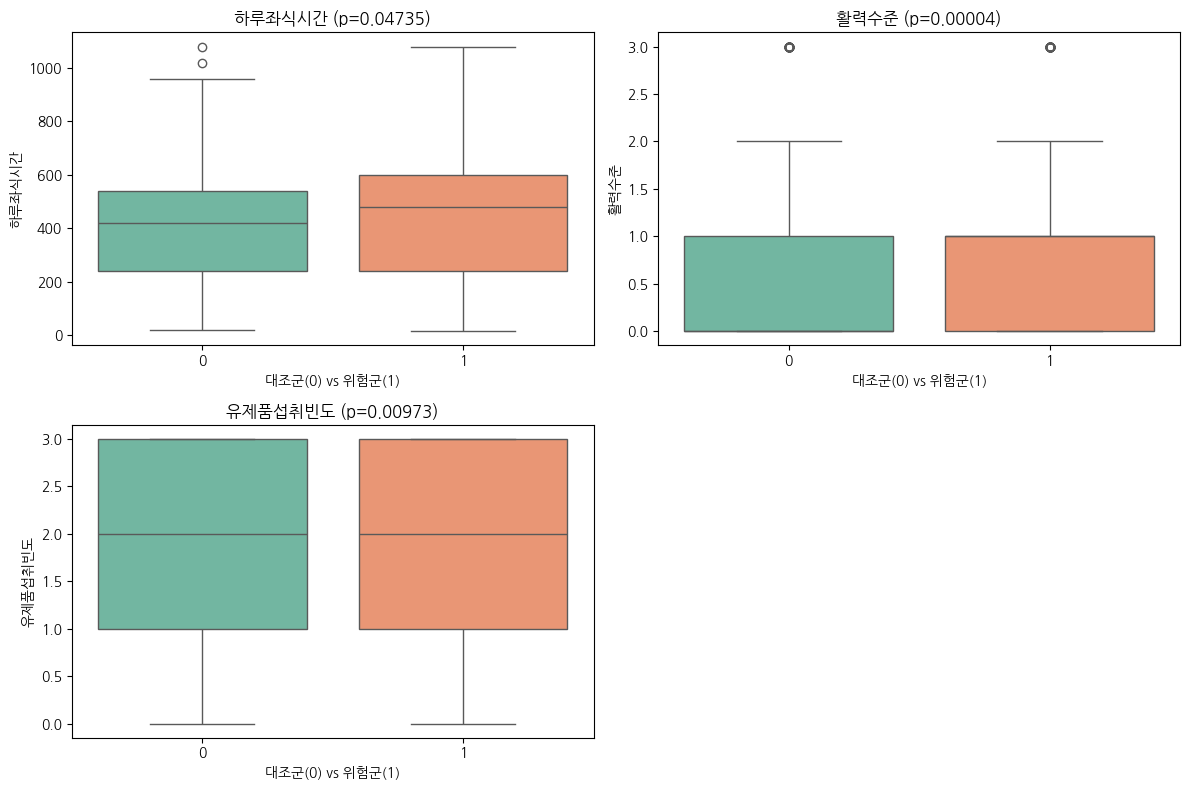

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sig_cont_cols = [
    ('하루좌식시간', 0.04735),
    ('활력수준', 0.00004),
    ('유제품섭취빈도', 0.00973)
]

plt.figure(figsize=(12, 8))
for i, (col, p) in enumerate(sig_cont_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df_40_70, x='대사증후군_위험군', y=col, palette='Set2')
    plt.title(f"{col} (p={p:.5f})")
    plt.xlabel("대조군(0) vs 위험군(1)")

plt.tight_layout()
plt.show()


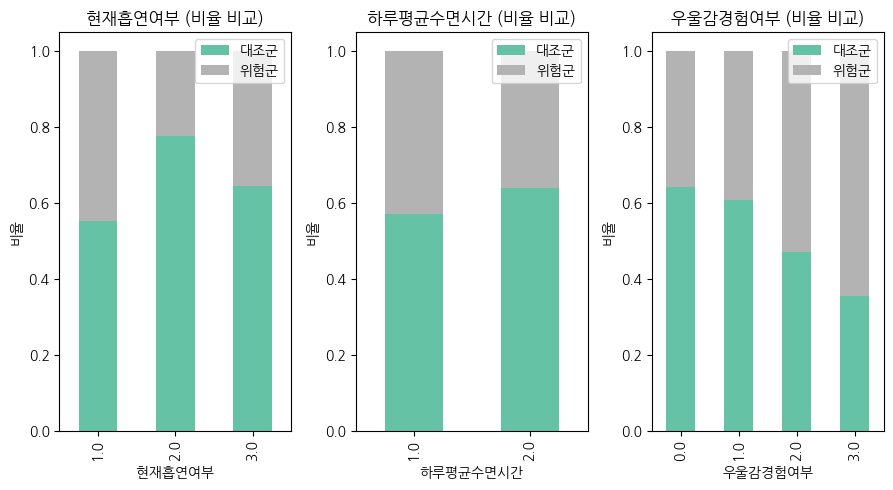

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cate_cols = ['현재흡연여부', '하루평균수면시간', '우울감경험여부']

plt.figure(figsize=(12, 5))
for i, col in enumerate(cate_cols, 1):
    plt.subplot(1, 4, i)
    table = pd.crosstab(df_40_70[col], df_40_70['대사증후군_위험군'], normalize='index')
    table.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set2')
    plt.title(f"{col} (비율 비교)")
    plt.ylabel("비율")
    plt.legend(["대조군", "위험군"])

plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats as stats
import numpy as np
import pandas as pd


# ==============================
# 1) Welch t-test (연속형 변수)
# ==============================
def welch_test_two_groups(df, group_col, group_a, group_b, col):
    print(f"\n=== {col}: {group_col} {group_a} vs {group_b} (Welch t-test) ===")

    a = df[df[group_col] == group_a][col].dropna()
    b = df[df[group_col] == group_b][col].dropna()

    if len(a) < 2 or len(b) < 2:
        print("표본 수가 부족합니다.")
        return

    # Welch t-test
    t, p = stats.ttest_ind(a, b, equal_var=False)

    # Cohen's d
    d = (a.mean() - b.mean()) / np.sqrt((a.std()**2 + b.std()**2) / 2)

    print(f"{group_a} 평균 = {a.mean():.2f}, {group_b} 평균 = {b.mean():.2f}")
    print(f"t = {t:.3f}, p = {p:.5f}")
    print(f"Cohen's d = {d:.3f}")

    if p < 0.05:
        print("➡ 유의한 차이가 있음")
    else:
        print("➡ 유의한 차이가 없음")



# ==============================
# 2) Chi-square (범주형 변수)
# ==============================
def chi_square_two_groups(df, group_col, group_a, group_b, col):
    print(f"\n=== {col}: {group_col} {group_a} vs {group_b} (Chi-square) ===")

    sub = df[df[group_col].isin([group_a, group_b])]
    table = pd.crosstab(sub[col], sub[group_col])

    if table.shape[0] < 2 or table.shape[1] < 2:
        print("교차표가 작아 검정 불가")
        return

    chi2, p, dof, expected = stats.chi2_contingency(table)

    # Cramer's V
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape
    cramer_v = np.sqrt(phi2 / (min(r - 1, k - 1)))

    print(table)
    print(f"chi2 = {chi2:.3f}, p = {p:.5f}, dof = {dof}")
    print(f"Cramer's V = {cramer_v:.3f}")

    if p < 0.05:
        print("➡ 유의한 차이가 있음")
    else:
        print("➡ 유의한 차이가 없음")



# ==============================
# 3) 분석 변수 리스트
# ==============================
continuous_cols = [
    '하루좌식시간',
    '유제품섭취빈도',
    '냉동식품섭취횟수',
    '1년 음주 빈도',
    '활력수준'
]

categorical_cols = [
    '커피섭취',
    '알콜섭취',
    '하루평균수면시간',
    '주당운동빈도',
    '우울감경험여부'
]



# ==============================
# 4) 실행: 흡연 3 vs 1,  흡연 3 vs 2
# ==============================
df_all = df  # 전체 데이터프레임으로 설정

pairs = [(3,1), (3,2)]  # 비교할 그룹 쌍

for g3, gx in pairs:
    print("\n" + "="*80)
    print(f"### 현재흡연여부 {g3}(비흡연) vs {gx} 비교 ###")
    print("="*80)

    # 연속형: Welch t-test
    for col in continuous_cols:
        if col in df_all.columns:
            welch_test_two_groups(df_all, '현재흡연여부', g3, gx, col)

    # 범주형: Chi-square
    for col in categorical_cols:
        if col in df_all.columns:
            chi_square_two_groups(df_all, '현재흡연여부', g3, gx, col)



### 현재흡연여부 3(비흡연) vs 1 비교 ###

=== 하루좌식시간: 현재흡연여부 3 vs 1 (Welch t-test) ===
3 평균 = 422.99, 1 평균 = 450.54
t = -3.519, p = 0.00044
Cohen's d = -0.143
➡ 유의한 차이가 있음

=== 유제품섭취빈도: 현재흡연여부 3 vs 1 (Welch t-test) ===
3 평균 = 1.88, 1 평균 = 1.91
t = -0.606, p = 0.54484
Cohen's d = -0.025
➡ 유의한 차이가 없음

=== 냉동식품섭취횟수: 현재흡연여부 3 vs 1 (Welch t-test) ===
3 평균 = 1.72, 1 평균 = 3.72
t = -5.262, p = 0.00000
Cohen's d = -0.215
➡ 유의한 차이가 있음

=== 1년 음주 빈도: 현재흡연여부 3 vs 1 (Welch t-test) ===
3 평균 = 3.90, 1 평균 = 3.18
t = 1.537, p = 0.12445
Cohen's d = 0.061
➡ 유의한 차이가 없음

=== 활력수준: 현재흡연여부 3 vs 1 (Welch t-test) ===
3 평균 = 0.66, 1 평균 = 0.65
t = 0.350, p = 0.72640
Cohen's d = 0.014
➡ 유의한 차이가 없음

=== 커피섭취: 현재흡연여부 3 vs 1 (Chi-square) ===
현재흡연여부   1.0   3.0
커피섭취              
1.0       10     9
2.0     1142  1275
chi2 = 0.056, p = 0.81229, dof = 1
Cramer's V = 0.005
➡ 유의한 차이가 없음

=== 알콜섭취: 현재흡연여부 3 vs 1 (Chi-square) ===
현재흡연여부   1.0   3.0
알콜섭취              
1.0        6    10
2.0     1146  1274
chi2 = 0.287, p = 0.59210, d

# 흡연 통계 검정

In [ ]:
import scipy.stats as stats
import numpy as np
import pandas as pd


# ==========================================
# 1) Welch t-test (연속형 변수)
# ==========================================
def welch_test_two_groups(df, col):
    df = df[['흡연자그룹', col]].dropna()

    group1 = df[df['흡연자그룹'] == 1][col]   # 흡연자(1,2)
    group0 = df[df['흡연자그룹'] == 0][col]   # 비흡연자(3)

    print(f"\n=== {col}: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===")

    if len(group1) < 2 or len(group0) < 2:
        print("표본 수 부족")
        return

    # Welch t-test
    t, p = stats.ttest_ind(group1, group0, equal_var=False)

    # Effect size: Cohen’s d
    d = (group1.mean() - group0.mean()) / np.sqrt((group1.std()**2 + group0.std()**2) / 2)

    print(f"흡연자 평균 = {group1.mean():.2f}, 비흡연자 평균 = {group0.mean():.2f}")
    print(f"t = {t:.3f}, p = {p:.5f}")
    print(f"Cohen's d = {d:.3f}")

    if p < 0.05:
        print("➡ 유의한 차이가 있음")
    else:
        print("➡ 유의한 차이가 없음")



# ==========================================
# 2) Chi-square (범주형 변수)
# ==========================================
def chi_square_two_groups(df, col):
    print(f"\n=== {col}: 흡연자(1+2) vs 비흡연자(3) (Chi-square) ===")

    sub = df[['흡연자그룹', col]].dropna()

    table = pd.crosstab(sub[col], sub['흡연자그룹'])

    if table.shape[0] < 2 or table.shape[1] < 2:
        print("교차표가 작아 검정 불가")
        return

    chi2, p, dof, expected = stats.chi2_contingency(table)

    # Effect size: Cramer's V
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape
    cramer_v = np.sqrt(phi2 / (min(r - 1, k - 1)))

    print(table)
    print(f"chi2 = {chi2:.3f}, p = {p:.5f}, dof = {dof}")
    print(f"Cramer's V = {cramer_v:.3f}")

    if p < 0.05:
        print("➡ 유의한 차이가 있음")
    else:
        print("➡ 유의한 차이가 없음")



# ==========================================
# 3) 분석 변수 리스트
# ==========================================
continuous_cols = [
    '하루좌식시간',
    '유제품섭취빈도',
    '냉동식품섭취횟수',
    '1년 음주 빈도',
    '활력수준'
]

categorical_cols = [
    '커피섭취',
    '알콜섭취',
    '하루평균수면시간',
    '주당운동빈도',
    '우울감경험여부'
]



# ==========================================
# 4) 흡연자 그룹 생성 (1+2=흡연자, 3=비흡연자)
# ==========================================
df_all = df  # 전체 데이터프레임 이름에 맞게 변경

df_all['흡연자그룹'] = df_all['현재흡연여부'].replace({
    1: 1,  # 매일
    2: 1,  # 가끔
    3: 0   # 피우지 않음
})



# ==========================================
# 5) 실행
# ==========================================
print("==============================================")
print("### 흡연자(1+2) vs 비흡연자(3) 비교 분석 ###")
print("==============================================")

# 연속형 → Welch t-test
for col in continuous_cols:
    if col in df_all.columns:
        welch_test_two_groups(df_all, col)

# 범주형 → Chi-square
for col in categorical_cols:
    if col in df_all.columns:
        chi_square_two_groups(df_all, col)


### 흡연자(1+2) vs 비흡연자(3) 비교 분석 ###

=== 하루좌식시간: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 441.12, 비흡연자 평균 = 422.99
t = 2.384, p = 0.01721
Cohen's d = 0.094
➡ 유의한 차이가 있음

=== 유제품섭취빈도: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 1.92, 비흡연자 평균 = 1.88
t = 0.850, p = 0.39518
Cohen's d = 0.033
➡ 유의한 차이가 없음

=== 냉동식품섭취횟수: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 3.48, 비흡연자 평균 = 1.72
t = 4.982, p = 0.00000
Cohen's d = 0.196
➡ 유의한 차이가 있음

=== 1년 음주 빈도: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 3.10, 비흡연자 평균 = 3.90
t = -1.721, p = 0.08552
Cohen's d = -0.068
➡ 유의한 차이가 없음

=== 활력수준: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 0.66, 비흡연자 평균 = 0.66
t = -0.080, p = 0.93594
Cohen's d = -0.003
➡ 유의한 차이가 없음

=== 커피섭취: 흡연자(1+2) vs 비흡연자(3) (Chi-square) ===
흡연자그룹   0.0   1.0
커피섭취             
1.0       9    10
2.0    1275  1287
chi2 = 0.000, p = 1.00000, dof = 1
Cramer's V = 0.000
➡ 유의한 차이가 없음

=== 알콜섭취: 흡연자(1+2) vs 비흡연자(3) (Chi-square) ===
흡연자그룹   0.0   1.0
알콜섭취             
1.0 

In [ ]:
import scipy.stats as stats
import numpy as np
import pandas as pd


# ==========================================
# 1) Welch t-test (연속형 변수)
# ==========================================
def welch_test_two_groups(df, col):
    df = df[['흡연자그룹', col]].dropna()

    group1 = df[df['흡연자그룹'] == 1][col]   # 흡연자(1,2)
    group0 = df[df['흡연자그룹'] == 0][col]   # 비흡연자(3)

    print(f"\n=== {col}: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===")

    if len(group1) < 2 or len(group0) < 2:
        print("표본 수 부족")
        return

    # Welch t-test
    t, p = stats.ttest_ind(group1, group0, equal_var=False)

    # Effect size: Cohen’s d
    d = (group1.mean() - group0.mean()) / np.sqrt((group1.std()**2 + group0.std()**2) / 2)

    print(f"흡연자 평균 = {group1.mean():.2f}, 비흡연자 평균 = {group0.mean():.2f}")
    print(f"t = {t:.3f}, p = {p:.5f}")
    print(f"Cohen's d = {d:.3f}")

    if p < 0.05:
        print("➡ 유의한 차이가 있음")
    else:
        print("➡ 유의한 차이가 없음")



# ==========================================
# 2) Chi-square (범주형 변수)
# ==========================================
def chi_square_two_groups(df, col):
    print(f"\n=== {col}: 흡연자(1+2) vs 비흡연자(3) (Chi-square) ===")

    sub = df[['흡연자그룹', col]].dropna()

    table = pd.crosstab(sub[col], sub['흡연자그룹'])

    if table.shape[0] < 2 or table.shape[1] < 2:
        print("교차표가 작아 검정 불가")
        return

    chi2, p, dof, expected = stats.chi2_contingency(table)

    # Effect size: Cramer's V
    n = table.values.sum()
    phi2 = chi2 / n
    r, k = table.shape
    cramer_v = np.sqrt(phi2 / (min(r - 1, k - 1)))

    print(table)
    print(f"chi2 = {chi2:.3f}, p = {p:.5f}, dof = {dof}")
    print(f"Cramer's V = {cramer_v:.3f}")

    if p < 0.05:
        print("➡ 유의한 차이가 있음")
    else:
        print("➡ 유의한 차이가 없음")



# ==========================================
# 3) 분석할 변수 리스트
# ==========================================
continuous_cols = [
    '하루좌식시간',
    '유제품섭취빈도',
    '냉동식품섭취횟수',
    '1년 음주 빈도',
    '활력수준'
]

categorical_cols = [
    '커피섭취',
    '알콜섭취',
    '수면장애여부',      # ← 여기 반영됨
    '주당운동빈도',
    '우울감경험여부'
]



# ==========================================
# 4) 흡연자 그룹 생성 (1+2=흡연자, 3=비흡연자)
# ==========================================
df_all = df  # 전체 데이터셋

df_all['흡연자그룹'] = df_all['현재흡연여부'].replace({
    1: 1,  # 매일
    2: 1,  # 가끔
    3: 0   # 피우지 않음
})



# ==========================================
# 5) 실행
# ==========================================
print("==============================================")
print("### 흡연자(1+2) vs 비흡연자(3) 비교 분석 ###")
print("==============================================")

# 연속형 → Welch t-test
for col in continuous_cols:
    if col in df_all.columns:
        welch_test_two_groups(df_all, col)

# 범주형 → Chi-square
for col in categorical_cols:
    if col in df_all.columns:
        chi_square_two_groups(df_all, col)


### 흡연자(1+2) vs 비흡연자(3) 비교 분석 ###

=== 하루좌식시간: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 441.12, 비흡연자 평균 = 422.99
t = 2.384, p = 0.01721
Cohen's d = 0.094
➡ 유의한 차이가 있음

=== 유제품섭취빈도: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 1.92, 비흡연자 평균 = 1.88
t = 0.850, p = 0.39518
Cohen's d = 0.033
➡ 유의한 차이가 없음

=== 냉동식품섭취횟수: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 3.48, 비흡연자 평균 = 1.72
t = 4.982, p = 0.00000
Cohen's d = 0.196
➡ 유의한 차이가 있음

=== 1년 음주 빈도: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 3.10, 비흡연자 평균 = 3.90
t = -1.721, p = 0.08552
Cohen's d = -0.068
➡ 유의한 차이가 없음

=== 활력수준: 흡연자(1+2) vs 비흡연자(3) (Welch t-test) ===
흡연자 평균 = 0.66, 비흡연자 평균 = 0.66
t = -0.080, p = 0.93594
Cohen's d = -0.003
➡ 유의한 차이가 없음

=== 커피섭취: 흡연자(1+2) vs 비흡연자(3) (Chi-square) ===
흡연자그룹   0.0   1.0
커피섭취             
1.0       9    10
2.0    1275  1287
chi2 = 0.000, p = 1.00000, dof = 1
Cramer's V = 0.000
➡ 유의한 차이가 없음

=== 알콜섭취: 흡연자(1+2) vs 비흡연자(3) (Chi-square) ===
흡연자그룹   0.0   1.0
알콜섭취             
1.0 

# 머신러닝 모델 비교

In [ ]:
# 기준 5개 합산
criteria_cols = ['허리둘레_기준','중성지방_기준','HDL_기준','혈압_기준','혈당_기준']
df['기준_충족수'] = df[criteria_cols].sum(axis=1)

# 대사증후군 위험군(1) vs 대조군(0)
df['대사증후군_위험군'] = (df['기준_충족수'] >= 3).astype(int)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier


# ================================
# 1) 분석 컬럼 설정
# ================================
features = [
    '하루좌식시간',
    '하루평균수면시간',
    '유제품섭취빈도',
    '현재흡연여부',
    '우울감경험여부',
    '활력수준',
    '냉동식품섭취횟수',
    '주당운동빈도',
    'BMI지수',
    '나이',
    '성별'
]

# ✅ 전체 데이터(df) 기반 – 40~70세 필터링 제거
df_model = df.dropna(subset=features + ['대사증후군_위험군']).copy()

# 데이터 준비
X = df_model[features]
y = df_model['대사증후군_위험군']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ================================
# 2) 개별 모델 정의 및 학습
# ================================
models = {}

# Logistic + scaling
logit_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, solver='lbfgs'))
])
logit_clf.fit(X_train, y_train)
models['Logistic'] = logit_clf

# RandomForest
rf_clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
models['RandomForest'] = rf_clf

# XGBoost
xgb_clf = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)
models['XGBoost'] = xgb_clf

# CatBoost
cat_clf = CatBoostClassifier(
    iterations=600,
    depth=6,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=False,
    random_seed=42
)
cat_clf.fit(X_train, y_train)
models['CatBoost'] = cat_clf

# Stacking
stack_clf = StackingClassifier(
    estimators=[
        ('logit', logit_clf),
        ('xgb', xgb_clf),
        ('cat', cat_clf)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)
stack_clf.fit(X_train, y_train)
models['Stacking'] = stack_clf


# ================================
# 3) 성능 평가 함수 & 결과 테이블 생성
# ================================
def model_metrics(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision(1)": precision_score(y_true, y_pred, zero_division=0),
        "Recall(1)": recall_score(y_true, y_pred, zero_division=0),
        "F1(1)": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_proba)
    }

results = {}

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)  # 기본 threshold 0.5
    results[name] = model_metrics(y_test, y_pred, y_proba)

df_results = pd.DataFrame(results).T.round(4)
df_results


,Accuracy,Precision(1),Recall(1),F1(1),AUC
Logistic,0.7911,0.6633,0.4643,0.5462,0.8344
RandomForest,0.7814,0.6337,0.4571,0.5311,0.8346
XGBoost,0.7911,0.6481,0.5000,0.5645,0.8330
CatBoost,0.7872,0.6415,0.4857,0.5528,0.8348
Stacking,0.7814,0.6337,0.4571,0.5311,0.8416


# XGBOOST

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb = models["XGBoost"]
y_proba = xgb.predict_proba(X_test)[:, 1]

# baseline
y_pred_base = (y_proba >= 0.5).astype(int)
base_acc = accuracy_score(y_test, y_pred_base)
base_recall = recall_score(y_test, y_pred_base)
print("Baseline Accuracy:", base_acc, "Baseline Recall:", base_recall)

# search thresholds
rows = []
for thr in np.arange(0.05, 0.90, 0.01):
    y_pred = (y_proba >= thr).astype(int)

    acc  = accuracy_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)

    rows.append({
        "threshold": thr,
        "Accuracy": acc,
        "Precision(1)": prec,
        "Recall(1)": rec,
        "F1(1)": f1,
        "AUC": auc
    })

df_thr = pd.DataFrame(rows)

# Accuracy를 baseline에서 0.01 이상 떨어지지 않는 범위로 제한
acc_min = base_acc - 0.01
df_cand = df_thr[df_thr["Accuracy"] >= acc_min]

# 이 중 Recall이 가장 큰 threshold 선택
best_row = df_cand.sort_values("Recall(1)", ascending=False).iloc[0]

best_row


Baseline Accuracy: 0.7911025145067698 Baseline Recall: 0.5


,31
threshold,0.360000
Accuracy,0.785300
Precision(1),0.586826
Recall(1),0.700000
F1(1),0.638436
AUC,0.833043


In [ ]:
best_thr = float(best_row["threshold"])
y_pred_opt = (y_proba >= best_thr).astype(int)

accuracy_score(y_test, y_pred_opt)
precision_score(y_test, y_pred_opt, zero_division=0)
recall_score(y_test, y_pred_opt, zero_division=0)
f1_score(y_test, y_pred_opt, zero_division=0)


0.6384364820846905

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 모델 리스트(models)와 X_test, y_test는 이미 존재한다고 가정

def find_best_threshold(model, X_test, y_test):

    # baseline
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred_base = (y_proba >= 0.5).astype(int)

    base_acc = accuracy_score(y_test, y_pred_base)
    acc_limit = base_acc - 0.01     # 정확도 손실 제한: -1% 이내

    rows = []
    for thr in np.arange(0.05, 0.90, 0.01):
        y_pred = (y_proba >= thr).astype(int)

        acc  = accuracy_score(y_test, y_pred)
        rec  = recall_score(y_test, y_pred, zero_division=0)
        prec = precision_score(y_test, y_pred, zero_division=0)
        f1   = f1_score(y_test, y_pred, zero_division=0)
        auc  = roc_auc_score(y_test, y_proba)

        rows.append({
            "threshold": thr,
            "Accuracy": acc,
            "Precision(1)": prec,
            "Recall(1)": rec,
            "F1(1)": f1,
            "AUC": auc
        })

    df_thr = pd.DataFrame(rows)

    # 정확도 유지 조건 적용
    df_cand = df_thr[df_thr["Accuracy"] >= acc_limit]

    # recall 최대값 선택
    best = df_cand.sort_values("Recall(1)", ascending=False).iloc[0]

    return best


# ============================
# 모든 모델에 대해 threshold 최적화 실행
# ============================
best_results = {}

for name, model in models.items():
    best_results[name] = find_best_threshold(model, X_test, y_test)

df_best = pd.DataFrame(best_results).T
df_best


,threshold,Accuracy,Precision(1),Recall(1),F1(1),AUC
Logistic,0.33,0.783366,0.584337,0.692857,0.633987,0.834388
RandomForest,0.36,0.771760,0.561111,0.721429,0.631250,0.834596
XGBoost,0.36,0.785300,0.586826,0.700000,0.638436,0.833043
CatBoost,0.35,0.779497,0.578313,0.685714,0.627451,0.834786
Stacking,0.26,0.785300,0.580110,0.750000,0.654206,0.841569


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 로지스틱 모델 선택
log_model = models["Logistic"]

# 예측 확률
y_proba = log_model.predict_proba(X_test)[:, 1]

# threshold = 0.4 적용
threshold = 0.4
y_pred = (y_proba >= threshold).astype(int)

# 성능 계산
logistic_results_04 = {
    "Threshold": threshold,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision(1)": precision_score(y_test, y_pred, zero_division=0),
    "Recall(1)": recall_score(y_test, y_pred, zero_division=0),
    "F1(1)": f1_score(y_test, y_pred, zero_division=0),
    "AUC": roc_auc_score(y_test, y_proba)
}

pd.DataFrame([logistic_results_04])


,Threshold,Accuracy,Precision(1),Recall(1),F1(1),AUC
0,0.4,0.800774,0.635036,0.621429,0.628159,0.834388


In [ ]:
# baseline 세팅
y_pred_base = (y_proba >= 0.5).astype(int)
base_acc = accuracy_score(y_test, y_pred_base)

acc_limit = base_acc - 0.01  # 정확도 1%p까지만 허용

cand = df_log_thr[df_log_thr["Accuracy"] >= acc_limit]

# 이 안에서 recall이 제일 큰 threshold 선택
best_row = cand.sort_values("Recall(1)", ascending=False).iloc[0]
best_row


,28
threshold,0.330000
Accuracy,0.783366
Precision(1),0.584337
Recall(1),0.692857
F1(1),0.633987
AUC,0.834388


In [ ]:
best_thr = float(best_row["threshold"])
y_pred_best = (y_proba >= best_thr).astype(int)

print("thr =", best_thr)
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_best, zero_division=0))
print("F1       :", f1_score(y_test, y_pred_best, zero_division=0))
print("AUC      :", roc_auc_score(y_test, y_proba))


thr = 0.33
Accuracy : 0.7833655705996132
Precision: 0.5843373493975904
Recall   : 0.6928571428571428
F1       : 0.6339869281045751
AUC      : 0.8343880257673361


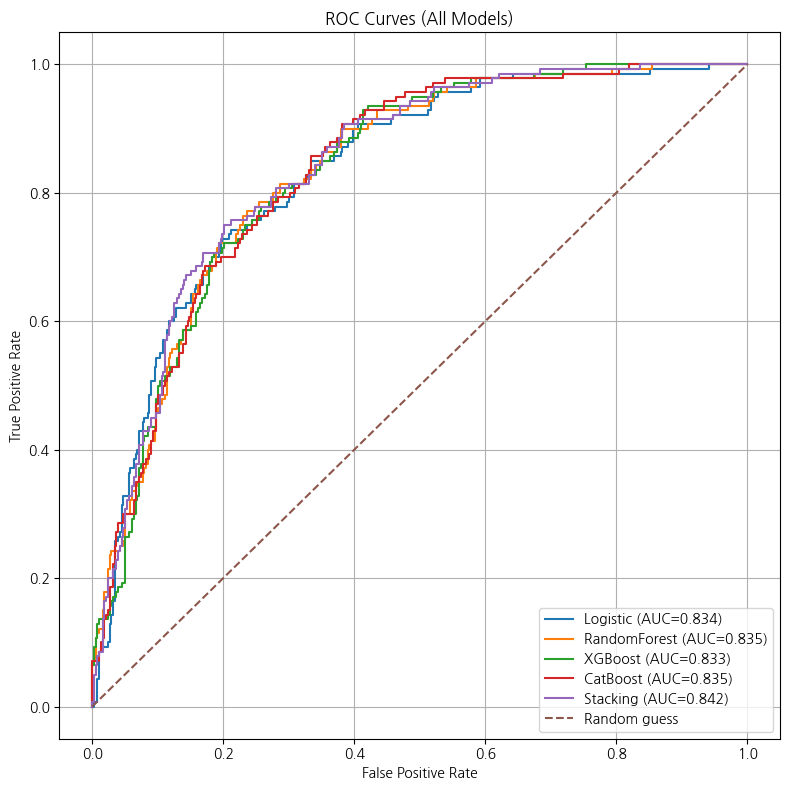

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# models : {"Logistic": ..., "RandomForest": ..., "XGBoost": ..., "CatBoost": ..., "Stacking": ...}
# X_test, y_test 가 이미 준비되어 있다고 가정

plt.figure(figsize=(8, 8))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# 무작위 분류 기준선
plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (All Models)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
def xgb_importance(model, feature_names):
    imp = model.feature_importances_
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": imp
    }).sort_values("importance", ascending=False)
    return df_imp


In [ ]:
xgb_imp = xgb_importance(models["XGBoost"], X.columns)
xgb_imp


,feature,importance
8,BMI지수,0.206741
9,나이,0.138785
3,현재흡연여부,0.089557
4,우울감경험여부,0.088672
10,성별,0.078639
7,주당운동빈도,0.074858
2,유제품섭취빈도,0.074213
5,활력수준,0.069209
0,하루좌식시간,0.066894
6,냉동식품섭취횟수,0.058469


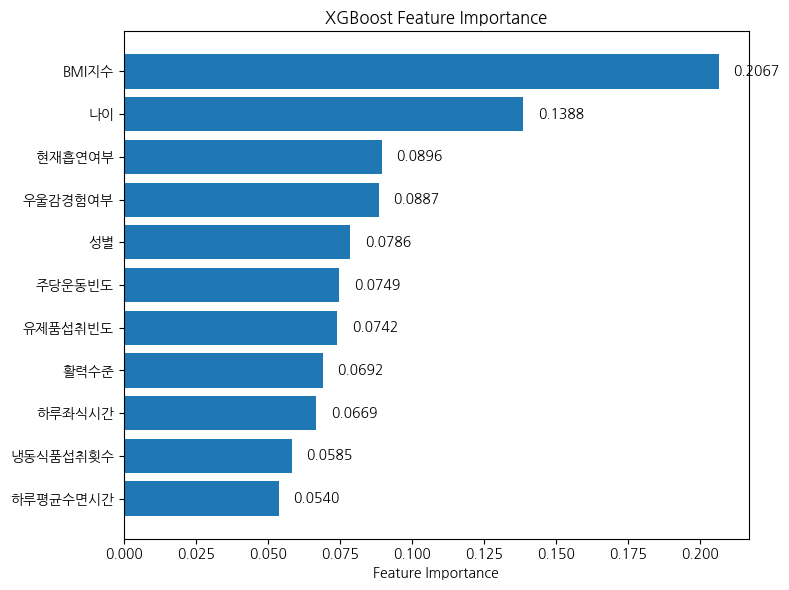

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# XGBoost 모델
xgb_model = models["XGBoost"]

# 중요도 추출
importances = xgb_model.feature_importances_
df_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
bars = plt.barh(df_imp["feature"], df_imp["importance"])

# 막대 값 표기 (오른쪽 끝에 수치 표시)
for bar, value in zip(bars, df_imp["importance"]):
    plt.text(
        bar.get_width() + 0.005,      # x 위치 (막대 끝 + 여유)
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",               # 소수점 4자리 표시
        va="center"
    )

plt.gca().invert_yaxis()  # 중요도 높은 순 위로
plt.xlabel("Feature Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()


In [ ]:
!pip install shap

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


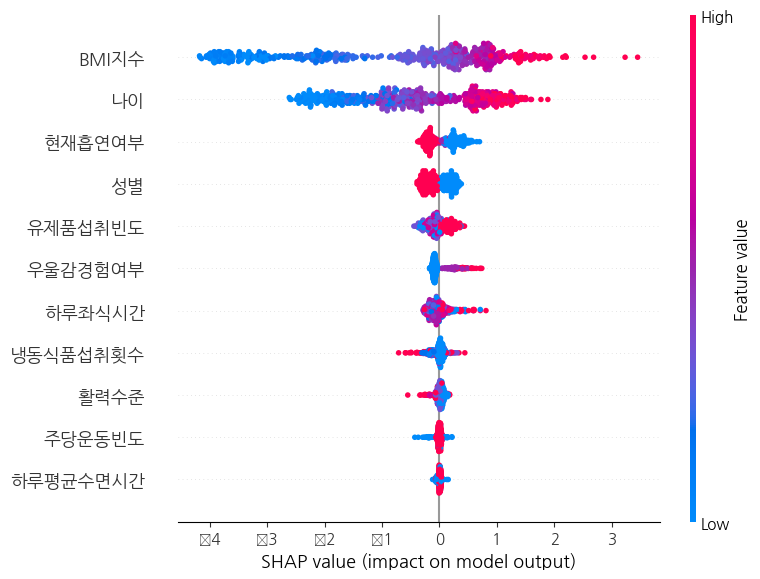

In [ ]:
import shap

# 1) SHAP용 explainer 생성 (TreeExplainer 사용)
xgb_model = models["XGBoost"]
explainer = shap.TreeExplainer(xgb_model)

# 2) SHAP 값 계산
shap_values = explainer.shap_values(X_test)

# 3) Summary plot (전체 변수 중요도 & 영향 방향)
shap.summary_plot(shap_values, X_test)


In [ ]:
df['냉동식품섭취횟수'].value_counts()

,count
냉동식품섭취횟수,
0,1608
1,260
2,194
4,105
3,88
10,56
5,53
8,33
11,32
